# Football Player Performance Analysis Using Machine Learning
**Regression + Classification + Clustering on one player-statistics dataset.**

Pipeline: Data -> Cleaning -> Features -> Train/Test split -> Models -> Evaluation -> Insights

Data: FBref Big-5 league player statistics (via `worldfootballR_data`), merged into `data/players.csv`
by `scripts/build_dataset.py`. One row per player per season. We analyse **one season** so each player appears once.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.cluster import KMeans
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, silhouette_score)

SEASON = 2024          # season ending year (2023-24)
MIN_MINUTES = 450      # drop players with too little playing time (per-90 rates are unstable)
RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

## 1. Load data

In [2]:
raw = pd.read_csv("data/players.csv")
print("All seasons:", raw.shape, "| seasons:", sorted(raw.Season.unique()))
df = raw[raw.Season == SEASON].copy()
print("Chosen season", SEASON, ":", df.shape)
df.head()

All seasons: (21703, 14) | seasons: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Chosen season 2024 : (2852, 14)


,Player,Team,League,Season,Pos,Age,Minutes,Goals,Assists,Shots,Passes,PassAcc,Tackles,Interceptions
16683,Abdel Abqar,Alavés,La Liga,2024,DF,25-081,2312.0,0.0,0.0,10.0,762.0,72.6,35.0,23.0
16684,Carlos Benavídez,Alavés,La Liga,2024,MF,26-061,1136.0,3.0,1.0,14.0,459.0,69.9,56.0,19.0
16685,Antonio Blanco,Alavés,La Liga,2024,MF,23-312,2426.0,0.0,1.0,20.0,1053.0,77.0,61.0,35.0
16686,Rubén Duarte,Alavés,La Liga,2024,DF,28-225,1878.0,2.0,1.0,15.0,827.0,68.4,39.0,23.0
16687,Andoni Gorosabel,Alavés,La Liga,2024,DF,27-300,2854.0,1.0,0.0,15.0,1329.0,79.7,62.0,28.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2852 entries, 16683 to 19534
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Player         2852 non-null   object 
 1   Team           2852 non-null   object 
 2   League         2852 non-null   object 
 3   Season         2852 non-null   int64  
 4   Pos            2852 non-null   object 
 5   Age            2847 non-null   object 
 6   Minutes        2852 non-null   float64
 7   Goals          2852 non-null   float64
 8   Assists        2852 non-null   float64
 9   Shots          2852 non-null   float64
 10  Passes         2849 non-null   float64
 11  PassAcc        2824 non-null   float64
 12  Tackles        2849 non-null   float64
 13  Interceptions  2852 non-null   float64
dtypes: float64(8), int64(1), object(5)
memory usage: 334.2+ KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Season,2852.0,2024.000000,0.000000,2024.0,2024.00,2024.00,2024.0,2024.0
Minutes,2852.0,1212.607293,961.244592,1.0,296.75,1112.50,1986.0,3420.0
Goals,2852.0,1.718443,3.201571,0.0,0.00,0.00,2.0,36.0
Assists,2852.0,1.220196,1.962800,0.0,0.00,0.00,2.0,14.0
Shots,2852.0,15.860098,19.598900,0.0,2.00,9.00,22.0,141.0
Passes,2849.0,612.830116,581.353302,0.0,116.00,457.00,966.0,3656.0
PassAcc,2824.0,77.134880,11.438757,0.0,71.50,78.25,84.5,100.0
Tackles,2849.0,20.326079,20.620059,0.0,3.00,15.00,32.0,152.0
Interceptions,2852.0,10.119565,11.908517,0.0,1.00,6.00,16.0,80.0


## 2. Cleaning
Steps: remove duplicates, remove goalkeepers (their outfield stats are not comparable), drop rows with missing
feature values, keep players with at least `MIN_MINUTES` minutes.

In [5]:
n0 = len(df)
df = df.drop_duplicates(subset=["Player", "Team"])
n1 = len(df)
print("Missing values before cleaning:\n", df.isna().sum()[df.isna().sum() > 0], "\n")
df = df[df.Pos != "GK"]
n2 = len(df)
df = df.dropna(subset=["Minutes", "Goals", "Assists", "Shots", "Passes", "PassAcc", "Tackles", "Interceptions"])
n3 = len(df)
df = df[df.Minutes >= MIN_MINUTES].reset_index(drop=True)
n4 = len(df)
print(f"rows: start {n0} -> dedupe {n1} -> no GK {n2} -> no NaN {n3} -> minutes >= {MIN_MINUTES}: {n4}")
print("Remaining missing values:", int(df.isna().sum().sum()))

Missing values before cleaning:
 Age         5
Passes      3
PassAcc    28
Tackles     3
dtype: int64 

rows: start 2852 -> dedupe 2852 -> no GK 2650 -> no NaN 2622 -> minutes >= 450: 1826
Remaining missing values: 1


## 3. Feature engineering
* **Per-90 rates** = count / minutes x 90, so players with different playing time are comparable.
* **Features (inputs):** Shots, Passes, Pass accuracy, Tackles, Interceptions.
* **Target (performance score)** = Goals/90 + Assists/90. This is a *project-defined* score, not an official rating.
* **Goals and Assists are NOT used as inputs**: they build the target, so using them would be target leakage.
* **Label:** High = score above the median, otherwise Low.

In [6]:
nineties = df.Minutes / 90
df["Shots_p90"] = df.Shots / nineties
df["Passes_p90"] = df.Passes / nineties
df["Tackles_p90"] = df.Tackles / nineties
df["Interceptions_p90"] = df.Interceptions / nineties
df["Goals_p90"] = df.Goals / nineties
df["Assists_p90"] = df.Assists / nineties

FEATURES = ["Shots_p90", "Passes_p90", "PassAcc", "Tackles_p90", "Interceptions_p90"]
df["Score"] = df.Goals_p90 + df.Assists_p90
threshold = df.Score.median()
df["Label"] = (df.Score > threshold).astype(int)    # 1 = High, 0 = Low

assert not {"Goals", "Assists", "Goals_p90", "Assists_p90", "Score"} & set(FEATURES)   # no leakage
print("Feature columns:", FEATURES)
print("Median score (threshold):", round(threshold, 3))
print("Class distribution:\n", df.Label.map({1: "High", 0: "Low"}).value_counts())
df[["Player", "Team", "Pos"] + FEATURES + ["Score", "Label"]].head()

Feature columns: ['Shots_p90', 'Passes_p90', 'PassAcc', 'Tackles_p90', 'Interceptions_p90']
Median score (threshold): 0.168
Class distribution:
 Label
Low     913
High    913
Name: count, dtype: int64


,Player,Team,Pos,Shots_p90,Passes_p90,PassAcc,Tackles_p90,Interceptions_p90,Score,Label
0,Abdel Abqar,Alavés,DF,0.389273,29.662630,72.6,1.362457,0.895329,0.000000,0
1,Carlos Benavídez,Alavés,MF,1.109155,36.364437,69.9,4.436620,1.505282,0.316901,1
2,Antonio Blanco,Alavés,MF,0.741962,39.064303,77.0,2.262984,1.298434,0.037098,0
3,Rubén Duarte,Alavés,DF,0.718850,39.632588,68.4,1.869010,1.102236,0.143770,0
4,Andoni Gorosabel,Alavés,DF,0.473020,41.909601,79.7,1.955151,0.882971,0.031535,0


## 4. Quick EDA

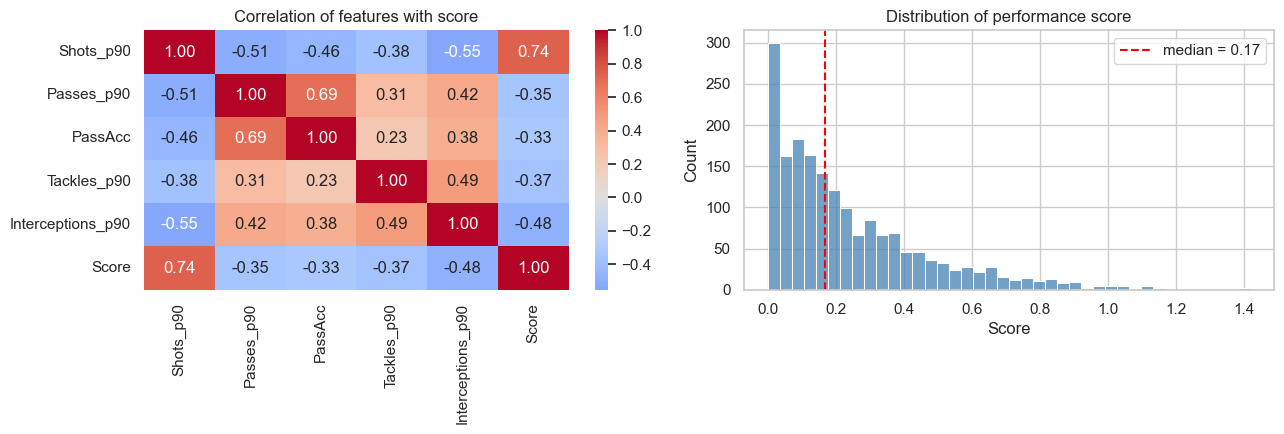

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.heatmap(df[FEATURES + ["Score"]].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax[0])
ax[0].set_title("Correlation of features with score")
sns.histplot(df.Score, bins=40, ax=ax[1], color="steelblue")
ax[1].axvline(threshold, color="red", ls="--", label=f"median = {threshold:.2f}")
ax[1].set_title("Distribution of performance score"); ax[1].legend()
plt.tight_layout(); plt.show()

## 5. Train / test split (80 / 20)
One split is shared by regression and classification (stratified on the High/Low label so both sets are balanced).
Scaling is done **inside pipelines**, so the scaler only ever sees training data.

In [8]:
X = df[FEATURES]
y_reg = df.Score
y_clf = df.Label
X_train, X_test, yr_train, yr_test, yc_train, yc_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf)
print("train:", X_train.shape, "test:", X_test.shape)
print("High share  train: %.2f  test: %.2f" % (yc_train.mean(), yc_test.mean()))

train: (1460, 5) test: (366, 5)
High share  train: 0.50  test: 0.50


## 6. Regression: Linear Regression vs Random Forest
Metrics: **MAE** (average error), **RMSE** (large errors count more), **R2** (share of variation explained).

In [9]:
reg_models = {
    "Linear Regression": make_pipeline(StandardScaler(), LinearRegression()),
    "Random Forest": RandomForestRegressor(n_estimators=300, min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=-1),
}
reg_rows, reg_pred = [], {}
for name, m in reg_models.items():
    m.fit(X_train, yr_train)
    p = m.predict(X_test); reg_pred[name] = p
    reg_rows.append({"Model": name,
                     "MAE": mean_absolute_error(yr_test, p),
                     "RMSE": np.sqrt(mean_squared_error(yr_test, p)),
                     "R2": r2_score(yr_test, p)})
reg_results = pd.DataFrame(reg_rows).set_index("Model").round(4)
reg_results

,MAE,RMSE,R2
Model,,,
Linear Regression,0.1110,0.1527,0.5591
Random Forest,0.1037,0.1439,0.6084


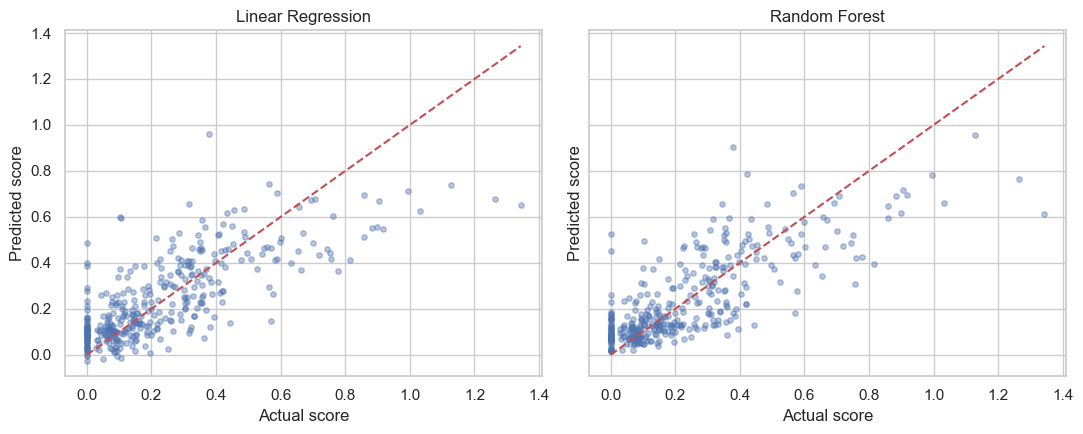

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)
for a, (name, p) in zip(ax, reg_pred.items()):
    a.scatter(yr_test, p, alpha=.4, s=15)
    lim = [0, max(yr_test.max(), p.max())]
    a.plot(lim, lim, "r--"); a.set_title(name); a.set_xlabel("Actual score"); a.set_ylabel("Predicted score")
plt.tight_layout(); plt.show()

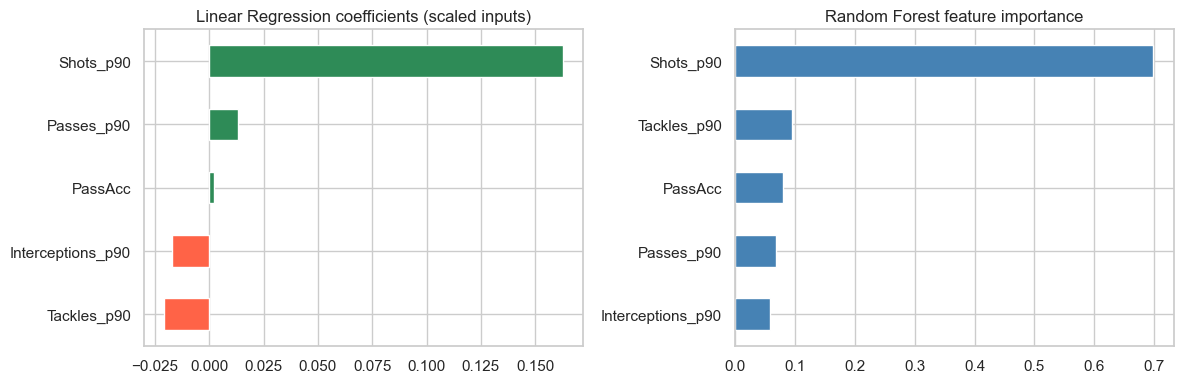

In [11]:
lin = reg_models["Linear Regression"].named_steps["linearregression"]
rf = reg_models["Random Forest"]
coef = pd.Series(lin.coef_, index=FEATURES).sort_values()
imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
coef.plot.barh(ax=ax[0], color=["tomato" if v < 0 else "seagreen" for v in coef]); ax[0].set_title("Linear Regression coefficients (scaled inputs)")
imp.plot.barh(ax=ax[1], color="steelblue"); ax[1].set_title("Random Forest feature importance")
plt.tight_layout(); plt.show()

## 7. Classification: Logistic Regression vs Decision Tree
Metrics: **Accuracy, Precision** (TP/(TP+FP)), **Recall** (TP/(TP+FN)), **F1** (balance of both) and the **confusion matrix**.
Positive class = High performer.

In [12]:
clf_models = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE),
}
clf_rows, clf_pred = [], {}
for name, m in clf_models.items():
    m.fit(X_train, yc_train)
    p = m.predict(X_test); clf_pred[name] = p
    clf_rows.append({"Model": name,
                     "Accuracy": accuracy_score(yc_test, p),
                     "Precision": precision_score(yc_test, p),
                     "Recall": recall_score(yc_test, p),
                     "F1": f1_score(yc_test, p)})
clf_results = pd.DataFrame(clf_rows).set_index("Model").round(4)
clf_results

,Accuracy,Precision,Recall,F1
Model,,,,
Logistic Regression,0.8060,0.8373,0.7596,0.7966
Decision Tree,0.7978,0.8303,0.7486,0.7874


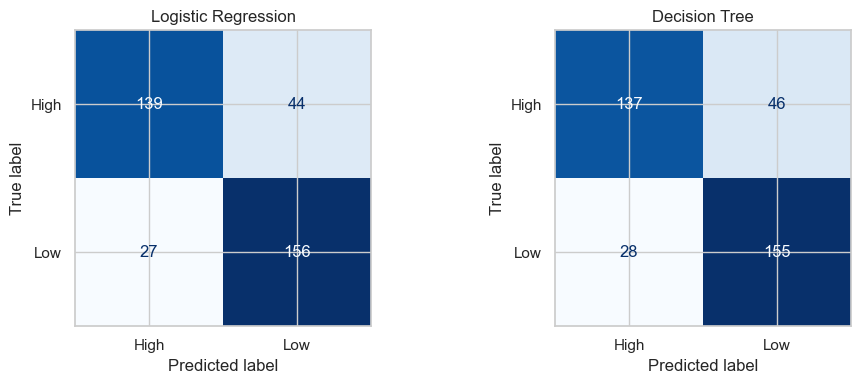

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for a, (name, p) in zip(ax, clf_pred.items()):
    ConfusionMatrixDisplay(confusion_matrix(yc_test, p, labels=[1, 0]), display_labels=["High", "Low"]).plot(ax=a, cmap="Blues", colorbar=False)
    a.set_title(name)
plt.tight_layout(); plt.show()

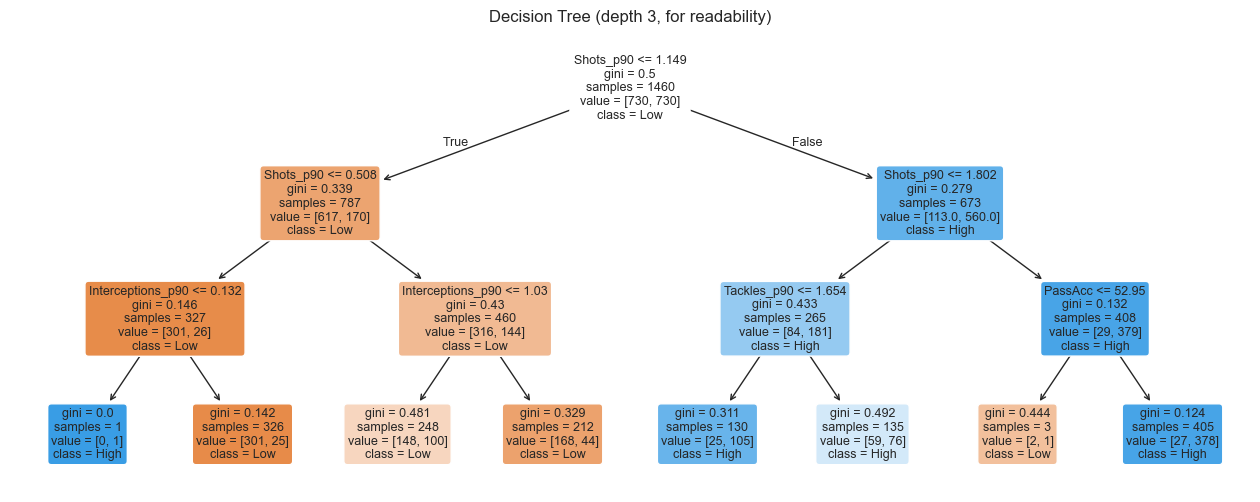

In [14]:
plt.figure(figsize=(16, 6))
plot_tree(DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE).fit(X_train, yc_train),
          feature_names=FEATURES, class_names=["Low", "High"], filled=True, rounded=True, fontsize=9)
plt.title("Decision Tree (depth 3, for readability)"); plt.show()

## 8. Cross-validation (how well do the models generalise?)
A single train/test split can be lucky or unlucky. **5-fold cross-validation** trains each model 5 times on different
80% slices of the *training* set and scores it on the held-out 20% slice each time. A small standard deviation means
the result is stable. The untouched test score is shown next to it for comparison.

In [15]:
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score
kf = KFold(5, shuffle=True, random_state=RANDOM_STATE)
skf = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
for name, m in reg_models.items():
    s = cross_val_score(m, X_train, yr_train, cv=kf, scoring="r2")
    cv_rows.append({"Task": "Regression (R2)", "Model": name, "CV mean": s.mean(), "CV std": s.std(),
                    "Test": reg_results.loc[name, "R2"], **{f"Fold {i+1}": v for i, v in enumerate(s)}})
for name, m in clf_models.items():
    s = cross_val_score(m, X_train, yc_train, cv=skf, scoring="accuracy")
    cv_rows.append({"Task": "Classification (Accuracy)", "Model": name, "CV mean": s.mean(), "CV std": s.std(),
                    "Test": clf_results.loc[name, "Accuracy"], **{f"Fold {i+1}": v for i, v in enumerate(s)}})
cv_results = pd.DataFrame(cv_rows).set_index(["Task", "Model"]).round(4)
cv_results

CV mean  CV std    Test  \
Task                      Model                                          
Regression (R2)           Linear Regression     0.5609  0.0396  0.5591   
                          Random Forest         0.5519  0.0276  0.6084   
Classification (Accuracy) Logistic Regression   0.7959  0.0257  0.8060   
                          Decision Tree         0.7767  0.0257  0.7978   

                                               Fold 1  Fold 2  Fold 3  Fold 4  \
Task                      Model                                                 
Regression (R2)           Linear Regression    0.5680  0.6236  0.5558  0.4991   
                          Random Forest        0.5601  0.5857  0.5677  0.5046   
Classification (Accuracy) Logistic Regression  0.7568  0.8116  0.8219  0.8151   
                          Decision Tree        0.7295  0.7705  0.7979  0.7877   

                                               Fold 5  
Task                      Model                        
Regression (R2)           Linear Regression    0.5577  
                          Random Forest        0.5416  
Classification (Accuracy) Logistic Regression  0.7740  
                          Decision Tree        0.7979

## 9. Clustering: K-Means
Unsupervised: no labels are used. Features are **scaled first** because K-Means works on distances.
K is chosen with the **elbow** (inertia) and **silhouette** (closer to 1 = players sit well inside their own cluster).

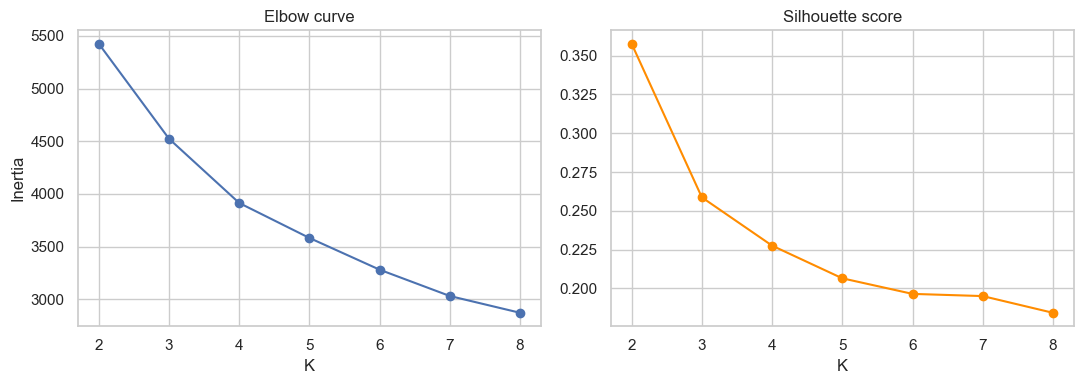

 K  Inertia  Silhouette
 2   5425.0       0.358
 3   4523.8       0.259
 4   3914.2       0.228
 5   3582.4       0.207
 6   3281.3       0.197
 7   3031.6       0.195
 8   2872.4       0.184


In [16]:
scaler_km = StandardScaler().fit(df[FEATURES])
Xs = scaler_km.transform(df[FEATURES])
ks = range(2, 9)
inertia, sil = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(Xs)
    inertia.append(km.inertia_); sil.append(silhouette_score(Xs, km.labels_))
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(list(ks), inertia, "o-"); ax[0].set_title("Elbow curve"); ax[0].set_xlabel("K"); ax[0].set_ylabel("Inertia")
ax[1].plot(list(ks), sil, "o-", color="darkorange"); ax[1].set_title("Silhouette score"); ax[1].set_xlabel("K")
plt.tight_layout(); plt.show()
print(pd.DataFrame({"K": list(ks), "Inertia": np.round(inertia, 1), "Silhouette": np.round(sil, 3)}).to_string(index=False))

In [17]:
# Choose K: best silhouette among 3..6 (at least 3 groups so the profiles are interesting)
cand = {k: s for k, s in zip(ks, sil) if 3 <= k <= 6}
K = max(cand, key=cand.get)
kmeans = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE).fit(Xs)
df["Cluster"] = kmeans.labels_
print("Chosen K =", K, "| silhouette =", round(silhouette_score(Xs, kmeans.labels_), 3))
profile = df.groupby("Cluster")[FEATURES + ["Score"]].mean().round(2)
profile.insert(0, "Players", df.Cluster.value_counts().sort_index())
profile

Chosen K = 3 | silhouette = 0.259


,Players,Shots_p90,Passes_p90,PassAcc,Tackles_p90,Interceptions_p90,Score
Cluster,,,,,,,
0,602,2.35,30.42,71.83,1.07,0.36,0.44
1,546,0.72,62.21,86.42,1.59,0.97,0.13
2,678,0.85,44.87,77.62,2.27,1.08,0.13


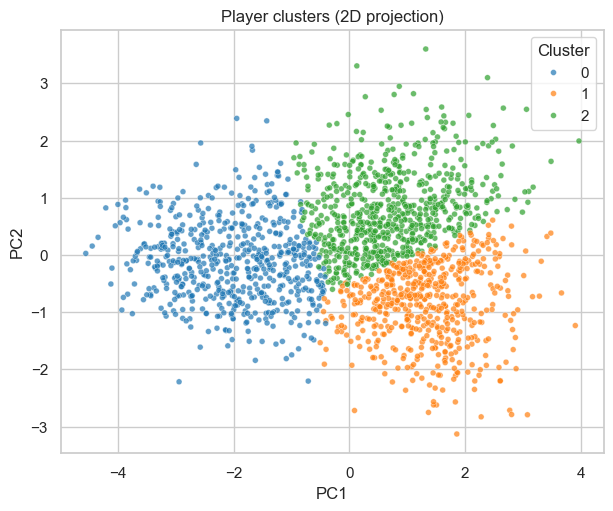

Position mix per cluster (rows = cluster):


Pos,DF,FW,MF
Cluster,,,
0,0.03,0.69,0.28
1,0.69,0.01,0.30
2,0.57,0.05,0.38


In [18]:
from sklearn.decomposition import PCA
pc = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(Xs)   # PCA only for the 2D picture
plt.figure(figsize=(7, 5.5))
sns.scatterplot(x=pc[:, 0], y=pc[:, 1], hue=df.Cluster, palette="tab10", s=18, alpha=.7)
plt.title("Player clusters (2D projection)"); plt.xlabel("PC1"); plt.ylabel("PC2"); plt.show()
print("Position mix per cluster (rows = cluster):")
pd.crosstab(df.Cluster, df.Pos.str.split(",").str[0], normalize="index").round(2)

## 10. Naming the clusters (only after looking at the numbers)
Names are derived from each cluster's *measured* profile: the feature on which the cluster is highest relative to the
other clusters decides its name. K-Means itself never sees these names. **Position is not an input** to the clustering,
so the position mix below is a useful sanity check: do the groups we found resemble real football roles?

In [19]:
z = (profile[FEATURES] - profile[FEATURES].mean()) / profile[FEATURES].std(ddof=0)   # cluster means vs other clusters
theme = {"Shots_p90": "Attacking", "Passes_p90": "Playmaking", "PassAcc": "Playmaking",
         "Tackles_p90": "Defensive", "Interceptions_p90": "Defensive"}
cluster_names, used = {}, {}
for c in z.index:
    base = theme[z.loc[c].idxmax()]
    used[base] = used.get(base, 0) + 1
    cluster_names[c] = base if used[base] == 1 else f"{base} {used[base]}"
df["Profile"] = df.Cluster.map(cluster_names)
print("Cluster names:", cluster_names)
display(z.round(2).rename(index=cluster_names))
print("Position mix inside each cluster:")
pd.crosstab(df.Profile, df.Pos.str.split(",").str[0], normalize="index").round(2)

Cluster names: {0: 'Attacking', 1: 'Playmaking', 2: 'Defensive'}


,Shots_p90,Passes_p90,PassAcc,Tackles_p90,Interceptions_p90
Cluster,,,,,
Attacking,1.41,-1.19,-1.13,-1.17,-1.40
Playmaking,-0.79,1.26,1.30,-0.11,0.53
Defensive,-0.62,-0.07,-0.17,1.28,0.87


Position mix inside each cluster:


Pos,DF,FW,MF
Profile,,,
Attacking,0.03,0.69,0.28
Defensive,0.57,0.05,0.38
Playmaking,0.69,0.01,0.30


**Reading the clusters honestly**
* The "Playmaking" group is about 69% defenders, so it is better read as a **ball-playing profile** (most passes, best pass
  accuracy) than as a list of classic creative midfielders.
* The silhouette score (about 0.26) is low: the groups **overlap**. K=3 was chosen as a useful level of detail, not because the
  groups are cleanly separated.

**Limitation: position effect.** Player position is an important source of structure in the data. Some of the classification and
clustering signal therefore reflects positional differences rather than an independent measure of overall player quality.

Variance explained by PC1, PC2: 55.7%, 18.7%


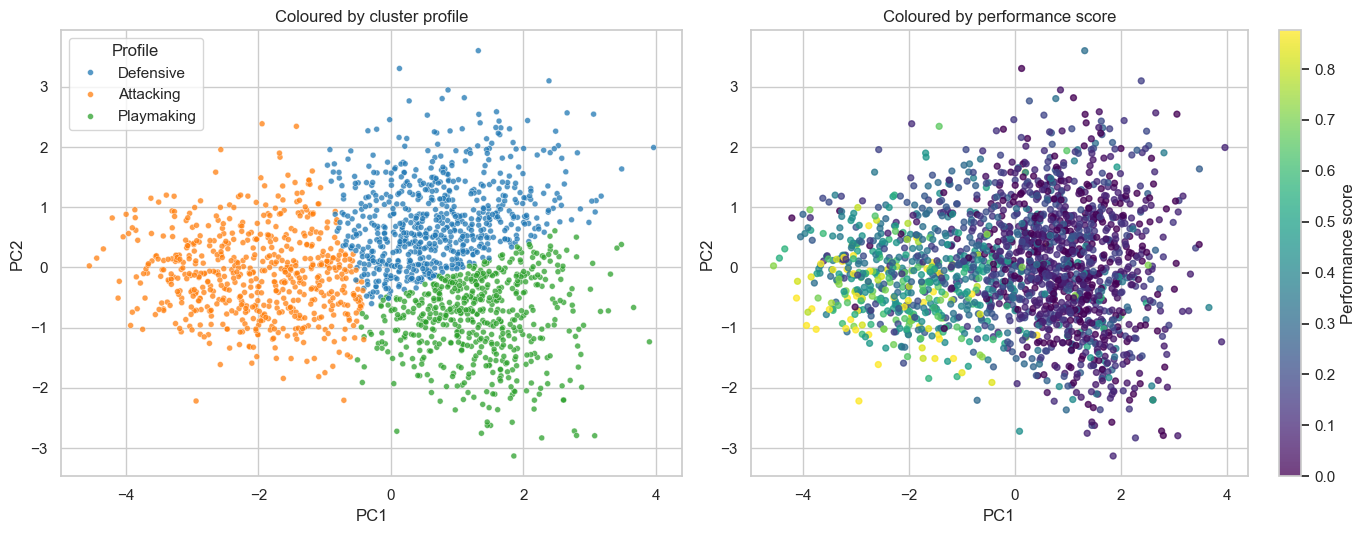

In [20]:
pca = PCA(n_components=2, random_state=RANDOM_STATE).fit(Xs)
pcs = pca.transform(Xs); df["PC1"], df["PC2"] = pcs[:, 0], pcs[:, 1]
print("Variance explained by PC1, PC2: %.1f%%, %.1f%%" % tuple(100 * pca.explained_variance_ratio_))
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
sns.scatterplot(data=df, x="PC1", y="PC2", hue="Profile", palette="tab10", s=18, alpha=.75, ax=ax[0])
ax[0].set_title("Coloured by cluster profile")
sc = ax[1].scatter(df.PC1, df.PC2, c=df.Score, cmap="viridis", s=18, alpha=.75, vmax=df.Score.quantile(.98))
plt.colorbar(sc, ax=ax[1], label="Performance score"); ax[1].set_title("Coloured by performance score")
for a in ax: a.set_xlabel("PC1"); a.set_ylabel("PC2")
plt.tight_layout(); plt.show()

## 11. Player similarity ("find players like X")
Every player is a point in the **scaled** 5-feature space. The nearest points (Euclidean distance) are the most
similar players. Similarity % = `100 x (1 - distance / largest distance from that player)`, a relative score
that is 100 for identical profiles and 0 for the most different player in the dataset.

In [21]:
from sklearn.neighbors import NearestNeighbors
nn = NearestNeighbors(n_neighbors=len(df)).fit(Xs)

def find_player(name):
    hit = df[df.Player.str.lower() == name.lower()]
    if hit.empty:
        hit = df[df.Player.str.lower().str.contains(name.lower(), regex=False)]
    if hit.empty:
        raise ValueError(f"No player matching '{name}' (players under {MIN_MINUTES} min / goalkeepers are excluded)")
    return hit.index[0]

def similar_players(name, n=5, same_position=False):
    i = find_player(name)
    dist, idx = nn.kneighbors(Xs[i:i + 1])
    dist, idx = dist[0], idx[0]
    out = df.iloc[idx].copy()
    out["Similarity %"] = (100 * (1 - dist / dist.max())).round(1)
    out = out.iloc[1:]                                     # drop the player themself
    if same_position:
        out = out[out.Pos.str.split(",").str[0] == df.loc[i, "Pos"].split(",")[0]]
    return out.head(n)[["Player", "Team", "Pos", "Profile", "Similarity %"] + FEATURES].round(2)

print("Query:", df.loc[find_player("Bukayo Saka"), ["Player", "Team", "Pos", "Profile"]].to_dict())
similar_players("Bukayo Saka")

Query: {'Player': 'Bukayo Saka', 'Team': 'Arsenal', 'Pos': 'FW', 'Profile': 'Attacking'}


,Player,Team,Pos,Profile,Similarity %,Shots_p90,Passes_p90,PassAcc,Tackles_p90,Interceptions_p90
664,Óscar Rodríguez Arnaiz,Getafe,"MF,FW",Attacking,92.7,3.16,41.14,75.3,2.23,0.47
837,Francisco Jesús Crespo García,Las Palmas,FW,Attacking,88.6,3.04,41.43,71.6,2.14,0.36
1078,Jeremy Doku,Manchester City,"FW,MF",Attacking,86.8,3.10,48.08,81.3,2.20,0.51
501,Junior Dina Ebimbe,Eint Frankfurt,"MF,DF",Attacking,85.4,2.39,43.02,76.5,2.02,0.41
913,Angelo Fulgini,Lens,MF,Attacking,84.5,3.01,51.61,72.1,1.50,0.52


In [22]:
similar_players('Rodri', n=5)

,Player,Team,Pos,Profile,Similarity %,Shots_p90,Passes_p90,PassAcc,Tackles_p90,Interceptions_p90
241,Alexis Saelemaekers,Bologna,"FW,MF",Defensive,95.0,1.38,48.08,78.0,1.53,0.62
844,Javier Muñoz,Las Palmas,MF,Defensive,92.2,1.30,43.81,79.2,1.43,0.68
1214,Patrick Ciurria,Monza,"DF,MF",Defensive,90.5,1.58,47.70,78.2,1.69,0.51
1129,Jordan Veretout,Marseille,MF,Playmaking,89.8,1.48,55.29,78.2,1.57,0.54
1620,Gvidas Gineitis,Torino,MF,Defensive,89.8,1.51,47.51,79.9,1.84,0.67


## 12. Scouting filters
Not a new model: a filter + ranking layer on top of the models we already trained. The table shows the **Random Forest
predicted score**, the **logistic-regression High/Low prediction** and the cluster profile.

> Displayed player predictions demonstrate model inference on the available player dataset; they are not a held-out evaluation.

In [23]:
df["Pred_Score"] = rf.predict(df[FEATURES]).round(3)
df["Pred_Category"] = np.where(clf_models["Logistic Regression"].predict(df[FEATURES]) == 1, "High", "Low")
df["Position"] = df.Pos.str.split(",").str[0].map({"DF": "Defender", "MF": "Midfielder", "FW": "Forward"})

def scout(position=None, min_score=0.0, min_pass_acc=0.0, min_tackles=0.0, profile=None, top=15, sort_by="Score"):
    q = df[(df.Score >= min_score) & (df.PassAcc >= min_pass_acc) & (df.Tackles_p90 >= min_tackles)]
    if position: q = q[q.Position == position]
    if profile:  q = q[q.Profile == profile]
    cols = ["Player", "Team", "Position", "Score", "Pred_Score", "Pred_Category", "Profile", "PassAcc", "Tackles_p90"]
    return q.sort_values(sort_by, ascending=False)[cols].head(top).round(2).reset_index(drop=True)

print("Midfielders with score >= 0.30, pass accuracy >= 80%, tackles >= 1.5 per 90:")
scout(position="Midfielder", min_score=0.30, min_pass_acc=80, min_tackles=1.5)

Midfielders with score >= 0.30, pass accuracy >= 80%, tackles >= 1.5 per 90:


,Player,Team,Position,Score,Pred_Score,Pred_Category,Profile,PassAcc,Tackles_p90
0,Kamory Doumbia,Brest,Midfielder,1.13,0.79,High,Defensive,86.2,2.87
1,Amine Adli,Leverkusen,Midfielder,1.00,0.71,High,Attacking,80.0,1.60
2,Adam Hložek,Leverkusen,Midfielder,0.98,0.67,High,Attacking,80.9,1.96
3,Jude Bellingham,Real Madrid,Midfielder,0.97,0.74,High,Playmaking,88.3,1.63
4,Marco Reus,Dortmund,Midfielder,0.79,0.62,High,Attacking,83.2,2.08
5,Jamal Musiala,Bayern Munich,Midfielder,0.77,0.61,High,Attacking,80.4,2.05
6,Giovani Lo Celso,Tottenham,Midfielder,0.71,0.68,High,Playmaking,89.3,3.91
7,Jeong Woo-yeong,Stuttgart,Midfielder,0.71,0.73,High,Defensive,84.4,2.13
8,Oussama El Azzouzi,Bologna,Midfielder,0.66,0.26,Low,Playmaking,90.3,1.97
9,Harvey Elliott,Liverpool,Midfielder,0.60,0.66,High,Attacking,83.7,1.80


In [24]:
scout(position='Forward', min_score=0.6, top=10)

,Player,Team,Position,Score,Pred_Score,Pred_Category,Profile,PassAcc,Tackles_p90
0,Kylian Mbappé,Paris S-G,Forward,1.42,1.09,High,Attacking,83.0,0.17
1,Harry Kane,Bayern Munich,Forward,1.39,1.02,High,Attacking,71.4,0.41
2,Cristhian Stuani,Girona,Forward,1.34,0.61,High,Attacking,73.0,1.57
3,Victor Boniface,Leverkusen,Forward,1.28,1.07,High,Attacking,72.2,0.35
4,Serhou Guirassy,Stuttgart,Forward,1.26,0.76,High,Attacking,81.0,0.24
5,Deniz Undav,Stuttgart,Forward,1.21,0.90,High,Attacking,74.5,1.21
6,Gianluca Scamacca,Atalanta,Forward,1.14,0.82,High,Attacking,67.6,0.95
7,Cole Palmer,Chelsea,Forward,1.14,0.84,High,Attacking,79.2,0.79
8,Michael Olise,Crystal Palace,Forward,1.13,0.88,High,Attacking,74.9,1.34
9,Erling Haaland,Manchester City,Forward,1.13,0.96,High,Attacking,76.0,0.21


## 13. Sanity checks
Automatic checks that the experiment is set up correctly (the cell fails loudly if anything is off).

In [25]:
# 1. no leakage: goals/assists (and anything built from them) are not model inputs
assert not {"Goals", "Assists", "Goals_p90", "Assists_p90", "Score", "Label"} & set(X.columns)
assert list(X.columns) == FEATURES and X.shape[1] == 5
# 2. no unexpected NaN / inf in the model inputs and targets
assert np.isfinite(X.to_numpy()).all() and np.isfinite(y_reg.to_numpy()).all()
# 3. split sizes and class balance
assert len(X_train) + len(X_test) == len(df) and abs(len(X_test) / len(df) - 0.2) < 0.01
assert abs(yc_train.mean() - 0.5) < 0.02 and abs(yc_test.mean() - 0.5) < 0.02
# 4. scaling lives inside pipelines (fit on training data only); trees/forest are unscaled
assert isinstance(reg_models["Linear Regression"].steps[0][1], StandardScaler)
assert isinstance(clf_models["Logistic Regression"].steps[0][1], StandardScaler)
assert not hasattr(reg_models["Random Forest"], "steps") and not hasattr(clf_models["Decision Tree"], "steps")
scaler_lr = clf_models["Logistic Regression"].steps[0][1]
assert np.allclose(scaler_lr.mean_, X_train.mean().to_numpy())      # scaler statistics come from the training rows only
# 5. all metrics are real numbers, silhouette is in [-1, 1]
assert np.isfinite(reg_results.to_numpy()).all() and np.isfinite(clf_results.to_numpy()).all()
assert -1 <= silhouette_score(Xs, kmeans.labels_) <= 1 and -1 <= min(sil) and max(sil) <= 1
print("All sanity checks passed.")

All sanity checks passed.


## 14. Results summary

In [26]:
print("REGRESSION (test set)");      display(reg_results)
print("CLASSIFICATION (test set)");  display(clf_results)
print("CROSS-VALIDATION (5-fold, on training set)"); display(cv_results[["CV mean", "CV std", "Test"]])
print(f"CLUSTERING: K={K}, silhouette={silhouette_score(Xs, kmeans.labels_):.3f}, inertia={kmeans.inertia_:.1f}")

REGRESSION (test set)


,MAE,RMSE,R2
Model,,,
Linear Regression,0.1110,0.1527,0.5591
Random Forest,0.1037,0.1439,0.6084


CLASSIFICATION (test set)


,Accuracy,Precision,Recall,F1
Model,,,,
Logistic Regression,0.8060,0.8373,0.7596,0.7966
Decision Tree,0.7978,0.8303,0.7486,0.7874


CROSS-VALIDATION (5-fold, on training set)


CV mean  CV std    Test
Task                      Model                                       
Regression (R2)           Linear Regression     0.5609  0.0396  0.5591
                          Random Forest         0.5519  0.0276  0.6084
Classification (Accuracy) Logistic Regression   0.7959  0.0257  0.8060
                          Decision Tree         0.7767  0.0257  0.7978

CLUSTERING: K=3, silhouette=0.259, inertia=4523.8


## 15. Save artifacts
Everything the Streamlit app needs is written to `models/`, so the app never retrains anything.

In [27]:
import joblib, os
os.makedirs("models", exist_ok=True)
imp_df = pd.DataFrame({"Random Forest importance": rf.feature_importances_,
                       "Linear coefficient (scaled)": lin.coef_}, index=FEATURES)
joblib.dump({
    "features": FEATURES, "threshold": float(threshold), "season": SEASON, "k": K,
    "cluster_names": cluster_names, "cluster_profile": profile, "cluster_z": z,
    "scaler_km": scaler_km, "kmeans": kmeans, "pca": pca,
    "reg_models": reg_models, "clf_models": clf_models,
    "reg_results": reg_results, "clf_results": clf_results, "cv_results": cv_results,
    "importances": imp_df,
    "k_table": pd.DataFrame({"K": list(ks), "Inertia": inertia, "Silhouette": sil}),
    "test_preds": {"reg": reg_pred, "clf": clf_pred, "y_reg": yr_test.values, "y_clf": yc_test.values},
}, "models/artifacts.joblib")
keep = ["Player", "Team", "League", "Pos", "Position", "Age", "Minutes", "Goals", "Assists"] + FEATURES + \
       ["Score", "Label", "Pred_Score", "Pred_Category", "Cluster", "Profile", "PC1", "PC2"]
df[keep].to_csv("models/players_scored.csv", index=False)
print("saved:", sorted(os.listdir("models")))

saved: ['artifacts.joblib', 'players_scored.csv']
